---
jupyter:
  hide_input: true
header-includes:
  - \usepackage{graphicx}
  - \usepackage{caption}
  - \usepackage{float}
---

---

# **FP3 – Integration Benchmarks**
Comparison of numerical integration methods: Gauss–Legendre, Clenshaw–Curtis and trapezoidal rules on a set of benchmark functions.

---

# **Task 1 – Theory**
## **Trapezoidal rule**
The trapezoidal rule approximates the definite integral
$$\int_a^b f(x) \ dx$$
by partitioning the interval $[a,b]$ into $N$ subintervals of equal length $h = \frac{b-a}{N}$. On each subinterval, the function $f$ is approximated by a linear function, leading to the quadrature formula
$$\int_a^b f(x) \ dx \approx \sum_{k=1}^{N} \frac{f(x_{k-1}) + f(x_k)}{2} h, \quad \text{where} \ x_k = a + kh.$$

### **Two-dimensional trapezoidal rule**
In two dimensions, the trapezoidal rule is obtained as a tensor product of the one-dimensional formula. For a rectangular domain $[a,b] \times [c,d],$ it takes the form
$$\begin{aligned}
\int_a^b \int_c^d f(x,y),dy,dx \approx \frac{hk}{4} \Bigg(&
f(a,c)+f(b,c)+f(a,d)+f(b,d) + 2 \sum_{i=1}^{n-1} \bigl[f(x_i,c)+f(x_i,d)\bigr] \\
&+ 2 \sum_{j=1}^{n-1} \bigl[f(a,y_j)+f(b,y_j)\bigr] + 4 \sum_{i=1}^{n-1} \sum_{j=1}^{n-1} f(x_i,y_j)
\Bigg),
\end{aligned}$$
where 
$$h=\frac{b-a}{n}, \qquad k=\frac{d-c}{n}, \quad x_i = a + ih,\quad y_j = c + jk.$$
**Source:** [Simpson’s Rule in Two Dimensions, IEEE CSE KTU](https://ieeecsktu.github.io/numeric/chap06/SimpsonsRule2D.pdf)

## **Gauss–Legendre quadrature**
Gauss–Legendre quadrature is a Gaussian quadrature method for approximating definite integrals by evaluating the function at optimally chosen nodes (the zeros of the Legendre polynomials) with corresponding weights. On the reference interval $[-1,1],$ the method is defined as
$$\int_{-1}^1 f(x) \ dx \approx \sum_{i=1}^n w_i f(x_i),$$
where $n$ denotes the number of quadrature points, $x_i$ are the roots of the Legendre polynomial $P_n(x)$ and $w_i$ are the associated quadrature weights.

Gauss–Legendre quadrature is exact for all polynomials of degree up to $2n-1$ and provides very high accuracy for smooth functions.

### **Two-dimensional Gauss–Legendre quadrature**
In higher dimensions, Gauss–Legendre quadrature is constructed via tensor products of the one-dimensional rule. In two dimensions, the resulting formula on the square $[-1,1]^2$ is
$$\int_{-1}^1 \int_{-1}^1 f(x,y) \ dy \ dx \approx \sum_{i=1}^n \sum_{k=1}^n w_i w_k f(x_i, y_k).$$
**Source:** [Guermond, *Numerical Integration*, Texas A&M University](https://people.tamu.edu/~guermond/M661_FALL_2017/chap04.pdf)

## **Clenshaw–Curtis quadrature**
Clenshaw–Curtis quadrature approximates the integral of $f$ on $[-1,1]$ by intergrating its interpolating polynomial at Chebyshev points. These nodes are defined as
$$x_k = \cos\left(\frac{k\pi}{n}\right), \quad k = 0,\dots,n.$$

The interpolant $p_n$ of $f$ in these nodes satisfies
$$\int_{-1}^{1} f(x) \ dx \approx \int_{-1}^{1} p_n(x) \ dx = \sum_{k=0}^{n} f(x_k) w_k,$$
where the quadrature weights are defined by
$$w_k := \int_{-1}^1 l_k(x) dx, \quad  l_k(x) = \prod_{\substack{j=0 \\ j\neq k}}^n \frac{x-x_j}{x_k-x_j}.$$

However this formula can also have easier to implement form if we take into consideration that 
$$p_n(x)=\sum_{k=0}^n a_k T_k(x), \quad T_k(x)=cos(k \arccos(x)).$$
The Chebyshev polynomials satisfy
$$\int_{-1}^{1} T_k(x)\ dx = \begin{cases}
\dfrac{2}{1 - k^{2}}, & k \text{ even},\\
0, & k \text{ odd}. \end{cases},$$

so that 
$$\int_{-1}^1 p_n(x) \ dx = \sum_{k=0}^n a_k \int_{-1}^2 T_k(x) \ dx$$

reduces to a simple linear combination of the coefficients $a_k.$

These coefficients are easily computed from the samples $f(x_j)$ via the discrete cosine transform
$$a_k = \frac{f(1)}{n} + \frac{(-1)^k f(-1)}{n} + \frac{2}{n} \sum_{j=1}^{n-1}f\left(\cos\left(\frac{j\pi}{n}\right)\right)\cos\left(\frac{jk \pi}{n}\right)$$

**Source:** [Clenshaw, C.W., Curtis, A.R. A method for numerical integration on an automatic computer. Numer. Math. 2, 197–205 (1960)](https://link.springer.com/article/10.1007/BF01386223)

Clenshaw–Curtis quadrature exhibits rapid convergence for smooth functions and, despite relying on non-optimal nodes in the Gaussian sense, is often competitive with Gauss–Legendre quadrature in practical applications.

### **Two-dimensional Gauss–Legendre quadrature**
In higher dimensions, Clenshaw–Curtis quadrature is - as in Legendre-Gauss case - constructed via tensor products of the one-dimensional rule. 


# **Task 2 – Benchmark Integrals**

**Adnotation:** To avoid focusing on the specific properties of individual functions and instead emphasize the quality of their numerical approximation, we restrict our analysis to two-dimensional functions defined on the domain $[-1,1]^2.$ The functions that will be used for this examination are:

## **Holder Table Function**

**Type of function:** oscillatory

![Holder Table Function](figures/holder.png)

$$f(x_1,x_2) = -\left|\sin(x_1)\cos(x_2)\exp\left(\left|1-\frac{\sqrt{x_1^2+x_2^2}}{\pi}\right|\right)\right|$$

## **Levy Function**

**Type of function:** smooth, oscillatory.

![Levy Function](figures/levy.png)

$$f(x_1,x_2) = \sin^2(\pi w_1) + (w_1-1)^2 \left[1+10\sin^2(\pi w_1+1)\right] + (w_2-1)^2 \left[1+\sin^2(2\pi w_2)\right], \qquad  w_i = 1+\frac{x_i-1}{4}$$

## **Six-Hump Camel Function**

**Type of function:** smooth, rational.

![*Six-Hump Camel Function](figures/camel6.png)

$$f(x_1,x_2) = \left(4 - 2.1x_1^2 + \frac{x_1^4}{3}\right)x_1^2 + x_1x_2 + \left(-4 + 4x_2^2\right)x_2^2$$



# **Task 3 – Implementation**
Code with implementation of Trapezoidal rule, Gauss–Legendre quadrature and Clenshaw–Curtis quadrature is included in the file .ipynb


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import fixed_quad
from numpy.polynomial.legendre import leggauss
from numpy.polynomial.chebyshev import Chebyshev

##### BENCHMARK FUNCTIONS #####
def holder(x, y):
    return -np.abs(np.sin(x) * np.cos(y) * np.exp(np.abs(1 - np.sqrt(x**2 + y**2) / np.pi)))

def levy(x, y):
    w1 = 1 + (x - 1) / 4
    w2 = 1 + (y - 1) / 4
    return (np.sin(np.pi * w1)**2 + (w1 - 1)**2 * (1 + 10 * np.sin(np.pi * w1 + 1)**2) + (w2 - 1)**2 * (1 + np.sin(2 * np.pi * w2)**2))

def camel6(x, y):
    return ((4 - 2.1*(x**2) + (x**4)/3)*(x**2) + x*y + (-4 + 4*(y**2))*(y**2))

##### REFERENCE INTEGRAL #####
# We use high-precision legendre to estimate integral
def reference_integral(f, n = 2000):
#    def inner(x):
#        return fixed_quad(lambda y: f(x, y), -1, 1, n = n)[0]
#    return fixed_quad(inner, -1, 1, n = n)[0]
    return(integrate_method(f, n, method = "gl"))

##### CLENSHEW-CURTIS WEIGHTS #####
def clenshaw_curtis_weights(n):
    # indexes
    j = np.arange(0, n + 1)
    k = np.arange(0, n + 1)
    
    # Chebyshev points
    theta = np.pi * k / n
    x = np.cos(theta)

    # matrix C_jk := T_k(x_j) = cos(jk pi/n)
    C = np.cos(np.outer(j, k) * np.pi / n)

    # vector beta = integrals of T_k on [-1,1]
    beta = np.zeros(n + 1)
    beta[0] = 2
    for i in range(1, n + 1):
        if i % 2 == 0:
            beta[i] = 2 / (1 - i**2)
        else:
            beta[i] = 0

    # w = C^(-T) beta
    w = np.linalg.solve(C.T, beta)
    return x, w


##### NUMERICAL INTEGRATION METHODS IN 2ND DIMENSION #####
# n - numbers of nodes / subintervals
def integrate_method(f, n, method = "tr"):
    if method == "tr":
        x = np.linspace(-1, 1, n + 1)
        y = np.linspace(-1, 1, n + 1)
        h = 2 / n
        
        X, Y = np.meshgrid(x, y)
        F = f(X, Y)

        # 1D trapezoid weights [1,2,2,...,2,1]
        wx = np.ones(n + 1)
        wy = np.ones(n + 1)
        wx[1:-1] = 2
        wy[1:-1] = 2

        # 2D weights [1 corners, 2 on sides, 4 in the middle]
        W = np.outer(wx, wy)
        
        return (((h**2) / 4) * np.sum(W * F))

    elif method == "gl":
        # Legendre-Gauss nodes and weights
        x, wx = leggauss(n)
        y, wy = leggauss(n)
        
        X, Y = np.meshgrid(x, y)
        F = f(X, Y)

        # tensor product of weights
        W = np.outer(wx, wy)
        
        return np.sum(W * F)

    elif method == "cc":
        # Chebyshev nodes implemented
        x, w = clenshaw_curtis_weights(n)

        X, Y = np.meshgrid(x, x)
        F = f(X, Y)

        # tensor product of weights
        W = np.outer(w, w)

        return np.sum(W * F)

    else:
        raise ValueError("Unknown method")

##### PLOTTING ERROR #####
def errors(f, title):
    nvals = np.arange(2, 100, 1)
    ref = reference_integral(f)
    errors = {"tr": [], "gl": [], "cc": []}

    for n in nvals:
        for method in errors:
            approx = integrate_method(f, n, method)
            errors[method].append(abs(approx - ref))

    plt.figure()
    for m in errors:
        plt.semilogy(nvals, np.maximum(errors[m], 1e-16), label = m)
    plt.xlabel("n")
    plt.ylabel("absolute error")
    plt.title(title)
    plt.legend()
    plt.grid(True)

##### FINAL PLOTS #####
#errors(holder, "Holder function")
#errors(levy, "Levy function")
#errors(camel6, "Six-Hump Camel function")
#plt.show()

# **Task 4 – Comparison**

Compare accuracy and convergence as the number of nodes increases.

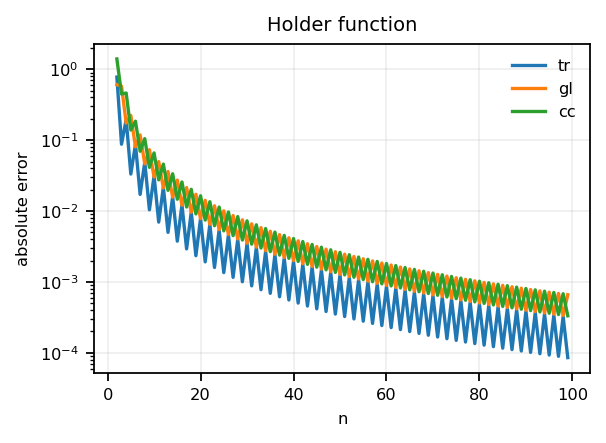

In [2]:
mpl.rcParams.update({
    "figure.figsize": (4, 8/3),
    "figure.dpi": 160,
    "savefig.dpi": 160,
    "font.size": 22/3,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "legend.frameon": False,
})
errors(holder, "Holder function")
plt.show()

**Reminder** Holder function is oscillatory.

The trapezoidal rule achieves the smallest errors for large values of $n$ despite its slower theoretical convergence rate as we can see for the highest $n.$ Gauss–Legendre and Clenshaw–Curtis initially converge faster, but their accuracy stagnates and remains above that of the trapezoidal rule as $n$ increases. This behavior is caused by the strong oscillations and lack of smoothness of the Holder function, which reduce the effectiveness of numerical methods.

As a result, the trapezoidal rule outperforms both Gauss–Legendre and Clenshaw–Curtis quadrature for sufficiently large numbers of nodes in this specific case.

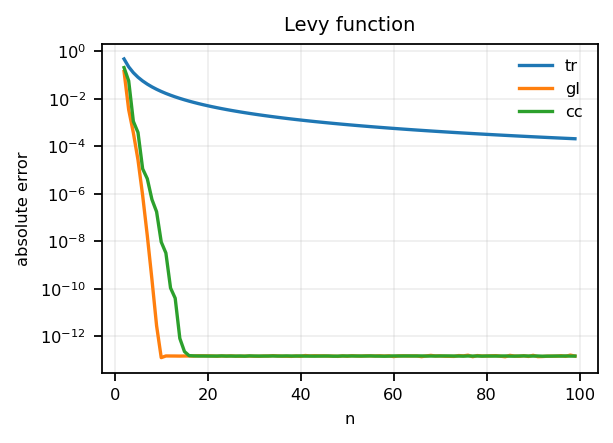

In [3]:
errors(levy, "Levy function")
plt.show()

**Reminder** Levy function is smooth and oscillatory.

Gauss–Legendre and Clenshaw–Curtis errors drop rapidly already for small $n \approx 15,$ reaching a near machine-precision plateau around $10^{-13}.$ In contrary, the trapezoidal rule converges much slower and remains a lot less accurate across the entire range of $n.$
Gauss–Legendre attains the plateau slightly earlier, while Clenshaw–Curtis follows closely and matches the same accuracy level. 

To conclude, both Gauss–Legendre and Clenshaw–Curtis vastly outperform the trapezoidal rule in both accuracy and convergence speed.

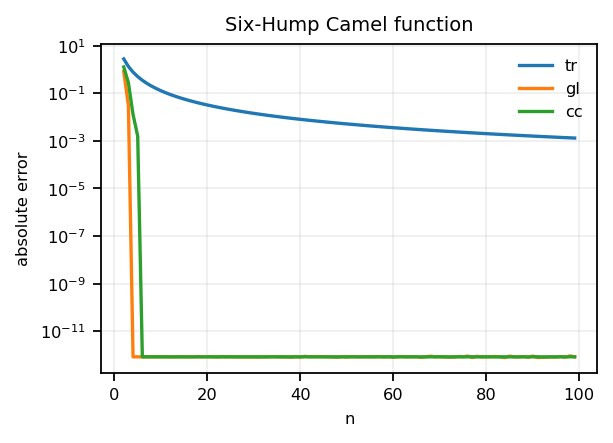

In [4]:
errors(camel6, "Six-Hump Camel function")
plt.show()

**Reminder** Six-Hump Camel function is smooth and rational.

As Six-Hump Camel function is also smooth, Gauss–Legendre and Clenshaw–Curtis quadrature  again converge extremely rapidly, reaching machine-precision accuracy after just a small number of nodes. Both methods exhibit nearly identical convergence behavior, with Gauss–Legendre achieving the plateau slightly earlier.

In contrast, the trapezoidal rule converges much slower and again remains much less accurate even for large $n.$ This confirms the clear advantage of spectral-type methods for smooth polynomial functions.


# **Task 5 – Discussion**

**The Trapezoidal Rule** is simple, but it converges slowly and is sensitive to oscillations, which limits its accuracy for smooth functions, but as we saw -  at the same time gives this method an advantage for oscillatory functions.

**Gauss–Legendre quadrature** provides very high accuracy and fast convergence for smooth integrands, but its performance can degrade for non-smooth functions plus this method requires computing non-uniform nodes and weights.

**Clenshaw–Curtis quadrature** offers accuracy comparable to Gauss–Legendre while being easier to implement and more numerically stable due to its use of Chebyshev nodes and FFT-based techniques.

Overall, trapezoidal methods are reliable but inefficient, while Gauss–Legendre and Clenshaw–Curtis are highly efficient for smooth function although lose the reliabilty when regularity is lost.